# 07 — Demo sveska (za odbranu projekta)

Sažeta, brza sveska koja **ne ponavlja** skupa računanja iz `01`-`05` (ta su već sačuvana u `data/processed/`), već ih učitava i rekapitulira ključne nalaze — namenjena za brzu, uživo demonstraciju tokom odbrane projekta.

**Napomena:** ova sveska pretpostavlja da su `01_priprema_i_analiza_podataka.ipynb` - `04_salsa.ipynb` pokrenute bar jednom (čime se popunjava `data/processed/`).

## Pregled projekta

- **Tema:** PageRank vs. HITS vs. SALSA — poređenje algoritama za rangiranje čvorova u usmerenim grafovima.
- **Pristup:** sva tri algoritma primenjena **globalno** nad istim usmerenim grafom (bez query-specifičnog root seta iz originalnih HITS/SALSA radova — obrazloženo u `README.md`).
- **Dataset:** [web-Stanford](https://snap.stanford.edu/data/web-Stanford.html) (SNAP) — 281.903 čvora, 2.312.497 hiperlinka.
- **Metodologija poređenja:** rang-korelacija (Spearman, Kendall's τ) i preklapanje top-k skupova, inspirisano radom Borodin et al. [6] — pošto (za razliku od referentnog Najork rada [5]) nemamo ljudske relevance labele.
- **Tri testirane hipoteze:** H1 (SALSA authority ≈ in-degree), H2 (HITS "gasi" čvorove van dominantne komponente), H3 (HITS i SALSA slabo korelisani uprkos istom grafu) — sve tri **potvrđene**, detaljno u `05_poredjenje_algoritama.ipynb`.

In [1]:
import itertools
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
SLIKE_DIR = PROJECT_ROOT / "slike"

PALETTE = {"pagerank": "#2a78d6", "hits": "#eb6834", "salsa": "#1baf7a", "baseline": "#eda100"}
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging", ["#e34948", "#f0efec", "#2a78d6"])
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
})

# --- Učitavanje SAČUVANIH rezultata iz svesaka 01-04 (bez ponovnog računanja) ---
A = sp.load_npz(DATA_PROCESSED / "web-stanford_adjacency.npz")
nodes = np.load(DATA_PROCESSED / "web-stanford_nodes.npy")
n = A.shape[0]
out_degree = np.asarray(A.sum(axis=1)).flatten()
in_degree = np.asarray(A.sum(axis=0)).flatten()

pagerank_scores = np.load(DATA_PROCESSED / "pagerank_scores.npy")
hits_hub = np.load(DATA_PROCESSED / "hits_hub_scores.npy")
hits_authority = np.load(DATA_PROCESSED / "hits_authority_scores.npy")
salsa_hub = np.load(DATA_PROCESSED / "salsa_hub_scores.npy")
salsa_authority = np.load(DATA_PROCESSED / "salsa_authority_scores.npy")

AUTH_GROUP = {"pagerank": pagerank_scores, "hits_authority": hits_authority,
              "salsa_authority": salsa_authority, "in_degree": in_degree}
HUB_GROUP = {"hits_hub": hits_hub, "salsa_hub": salsa_hub, "out_degree": out_degree}

print(f"Graf: {n:,} čvorova, {A.nnz:,} grana. Svi rezultati učitani (bez ponovnog računanja).")

Graf: 281,903 čvorova, 2,312,497 grana. Svi rezultati učitani (bez ponovnog računanja).


## 1. Sažetak hipoteza

In [2]:
def corr_matrix(group):
    names = list(group.keys())
    mat = pd.DataFrame(index=names, columns=names, dtype=float)
    for a, b in itertools.combinations_with_replacement(names, 2):
        if a == b:
            mat.loc[a, b] = 1.0
        else:
            rho, _ = spearmanr(group[a], group[b])
            mat.loc[a, b] = mat.loc[b, a] = rho
    return mat

auth_corr = corr_matrix(AUTH_GROUP)
hub_corr = corr_matrix(HUB_GROUP)
negligible = {name: (arr < 1e-10).sum() / n for name, arr in {**AUTH_GROUP, **HUB_GROUP}.items()}

summary = pd.DataFrame({
    "Hipoteza": ["H1", "H2", "H3"],
    "Tvrdnja": [
        "SALSA authority ∝ in-degree (na jednoj komponenti)",
        "HITS 'gasi' čvorove van dominantne komponente više od SALSA/PageRank-a",
        "HITS i SALSA daju slabo korelisana rangiranja, uprkos istom grafu",
    ],
    "Status": ["Potvrđena (nijansirano)", "Potvrđena", "Potvrđena"],
    "Ključna brojka": [
        f"ρ(SALSA-aut, in-deg) = {auth_corr.loc['salsa_authority', 'in_degree']:.2f}; egzaktno (0.00 razlika) na test-grafu jedne komponente",
        f"HITS: {negligible['hits_authority']:.0%} authority / {negligible['hits_hub']:.0%} hub ugašeno naspram SALSA {negligible['salsa_authority']:.0%}/{negligible['salsa_hub']:.1%}, PageRank {negligible['pagerank']:.0%}",
        f"ρ(HITS-aut, SALSA-aut) = {auth_corr.loc['hits_authority', 'salsa_authority']:.2f}; hub top-1000 preklapanje = 0%",
    ],
})
summary

,Hipoteza,Tvrdnja,Status,Ključna brojka
0,H1,SALSA authority ∝ in-degree (na jednoj kompone...,Potvrđena (nijansirano),"ρ(SALSA-aut, in-deg) = 0.79; egzaktno (0.00 ra..."
1,H2,HITS 'gasi' čvorove van dominantne komponente ...,Potvrđena,HITS: 64% authority / 48% hub ugašeno naspram ...
2,H3,"HITS i SALSA daju slabo korelisana rangiranja,...",Potvrđena,"ρ(HITS-aut, SALSA-aut) = -0.02; hub top-1000 p..."


## 2. Ključni grafik — matrica korelacija

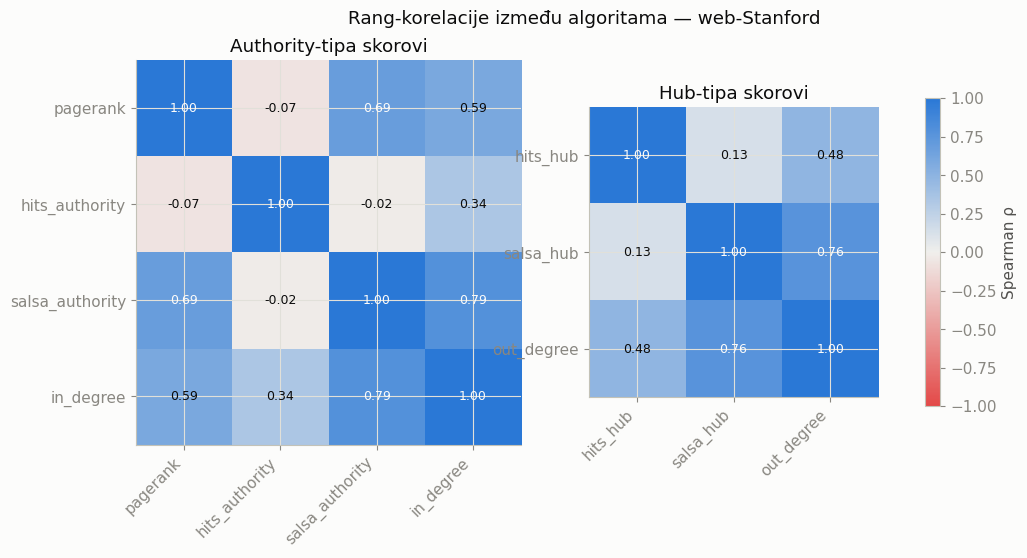

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [4, 3]})
for ax, mat, title in zip(axes, [auth_corr, hub_corr], ["Authority-tipa skorovi", "Hub-tipa skorovi"]):
    im = ax.imshow(mat.values.astype(float), cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
    ax.set_xticks(range(len(mat)), mat.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(mat)), mat.index)
    for i in range(len(mat)):
        for j in range(len(mat)):
            val = mat.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color=INK if abs(val) < 0.6 else "#fcfcfb", fontsize=9)
    ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.8, label="Spearman ρ")
fig.suptitle("Rang-korelacije između algoritama — web-Stanford")
plt.show()

## 3. Interaktivna provera — pogledajmo konkretan čvor

Funkcija ispod prima **originalni ID čvora** (iz dataset-a) i ispisuje njegov skor i rang po svakom algoritmu — praktična ilustracija koliko se rangiranja mogu razlikovati za isti čvor.

In [4]:
def uporedi_cvor(node_id):
    """Ispisuje skor i rang datog čvora (po originalnom ID-ju) kod svakog algoritma."""
    idx = np.where(nodes == node_id)[0]
    if len(idx) == 0:
        print(f"Čvor {node_id} ne postoji u grafu.")
        return
    idx = idx[0]

    print(f"Čvor {node_id}  (in-degree={int(in_degree[idx])}, out-degree={int(out_degree[idx])})")
    print("-" * 60)
    for name, arr in {**AUTH_GROUP, **HUB_GROUP}.items():
        rank = int((arr > arr[idx]).sum()) + 1  # rang 1 = najveći skor
        print(f"  {name:18s}: skor={arr[idx]:.6f}   rang={rank:,} / {n:,}")


# Primer: najbolji PageRank čvor iz Faze 2
uporedi_cvor(int(nodes[np.argsort(-pagerank_scores)[0]]))

Čvor 89073  (in-degree=15277, out-degree=64)
------------------------------------------------------------
  pagerank          : skor=0.011303   rang=1 / 281,903
  hits_authority    : skor=0.000012   rang=24,123 / 281,903
  salsa_authority   : skor=0.008369   rang=3 / 281,903
  in_degree         : skor=15277.000000   rang=12 / 281,903
  hits_hub          : skor=0.000000   rang=100,678 / 281,903
  salsa_hub         : skor=0.000033   rang=837 / 281,903
  out_degree        : skor=64.000000   rang=1,379 / 281,903


## 4. Zaključak projekta

- **PageRank, SALSA-authority i in-degree** međusobno slažu (ρ = 0,59–0,79) oko toga koji su čvorovi "bitni" u ovom web grafu.
- **HITS je iznenađujuće izolovan** — njegovo rangiranje je skoro nekorelisano i sa PageRank-om (ρ = -0,07) i sa SALSA-om (ρ = -0,02), uprkos radu nad identičnim ulaznim grafom. Ovo je robustan nalaz, potvrđen i kada se isključe HITS-ovi "ugašeni" čvorovi.
- **HITS "gasi" (skor ≈ 0) 64% authority i 48% hub skorova** — direktna posledica toga što je HITS matematički power-iteracija ka jednom dominantnom sopstvenom vektoru, dok PageRank (teleportacija) i SALSA (nezavisne stohastičke šetnje) tu "koncentraciju" izbegavaju.
- Nalazi su **kvalitativno konzistentni** sa referentnim Najork radom [5] (SALSA >> HITS kao izolovana karakteristika), uprkos tome što mi, bez relevance labela, koristimo drugačiju metodologiju (rang-korelacija između algoritama, ne IR metrike naspram ljudskih ocena).

Detaljni tok rada, sve implementacije i validacije: `01_priprema_i_analiza_podataka.ipynb` → `05_poredjenje_algoritama.ipynb`.
